#  Análisis de Machine Learning para TaskSync Pro

**Creador:** Diego Salvador Tecorralco Martinez \
**Materia:** Extracción de Conocimientos en Bases de Datos \
**periodo:** Mayo - Agosto 

## Descripción

Este notebook documenta el proceso completo de implementación de un sistema de Machine Learning para la plataforma TaskSync Pro. El objetivo es extraer conocimiento a partir de los datos de usuarios y recordatorios almacenados en la base de datos MySQL, con el fin de construir dos tipos de modelos:

- **Modelo Supervisado:** Predice el tiempo promedio (en horas) que un usuario tardará en completar una tarea, basándose en su historial de uso.

- **Modelo No Supervisado:** Segmenta a los usuarios en grupos (clusters) según su nivel de actividad y productividad, sin utilizar etiquetas previas.

Estos modelos se integran posteriormente en una API híbrida (Node.js + Python) para ser consumidos desde un frontend web o wearable, cumpliendo así con los requisitos de la Etapa 13 del Proyecto Integrador.

## Propósito

Este notebook documenta el proceso completo de implementación de un sistema de Machine Learning para la plataforma TaskSync Pro. 
Su objetivo es extraer conocimiento a partir de los datos de usuarios y recordatorios almacenados en la base de datos MySQL, 
con el fin de construir y evaluar modelos supervisados y no supervisados que luego se integran en una API híbrida (Node.js + Python).


## Tabla de contenido y funcionalidad por sección

| Sección | Título | ¿Qué hace? |
| :--- | :--- | :--- |
| **1** | Instalación de librerías extra | Instala `mysql-connector-python` y `python-dotenv` para conectar Python con MySQL y leer variables de entorno desde el archivo `.env`. |
| **2** | Importar librerías y cargar datos | Importa todas las librerías necesarias (pandas, numpy, matplotlib, seaborn, etc.), se conecta a la base de datos MySQL y extrae la vista `vw_ml_data` (Data Mart analítico) que contiene las métricas de cada usuario. |
| **3** | Estadísticas descriptivas y calidad de datos | Muestra estadísticas descriptivas (media, desviación, mín/máx) y verifica la presencia de valores nulos. Esto permite entender la estructura y calidad de los datos antes de modelar. |
| **4.1** | Distribución de tareas totales y horas promedio | Genera histogramas para visualizar cómo se distribuyen el número de tareas por usuario y el tiempo promedio para completarlas. |
| **4.2** | Relación entre tareas y horas promedio | Genera un scatter plot para observar si existe una tendencia entre el número de tareas y el tiempo promedio para completarlas. |
| **4.3** | Distribución de tareas completadas | Muestra un gráfico de barras con la cantidad de usuarios que tienen 0, 1, 2 o 3 tareas completadas. Útil para detectar desbalance de clases. |
| **4.4** | Matriz de correlación | Genera un mapa de calor con los coeficientes de correlación lineal entre las variables. Permite identificar relaciones fuertes entre variables. |
| **5** | Modelo Supervisado: Random Forest Regressor | Entrena un modelo Random Forest para predecir las horas promedio que un usuario tardará en completar una tarea. Evalúa con MSE y R². |
| **5.1** | Modelo Supervisado 2: Regresión Lineal | Entrena un modelo de Regresión Lineal como baseline para comparar con modelos más complejos. |
| **5.2** | Modelo Supervisado 3: Árbol de Decisión | Entrena un Árbol de Decisión para regresión. Permite comparar el rendimiento de un modelo simple frente a los de ensamble. |
| **5.3** | Modelo Supervisado 4: Gradient Boosting | Entrena un modelo de Gradient Boosting, que combina múltiples árboles de decisión de forma secuencial para mejorar la precisión. |
| **5.4** | Modelo Supervisado 5: K-Nearest Neighbors (KNN) | Entrena un modelo KNN para regresión, que predice basándose en la media de los vecinos más cercanos. |
| **5.5** | Comparación de Modelos Supervisados | Crea una tabla comparativa con todos los modelos supervisados (MSE y R²) y selecciona el mejor según la métrica de error (MSE). |
| **6** | Modelo No Supervisado: K-Means Clustering | Agrupa usuarios en clusters utilizando K-Means. Prueba K de 2 a 5 y evalúa con el método del codo y Silhouette Score para elegir el mejor K. |
| **6.1** | Modelo No Supervisado 2: DBSCAN | Aplica DBSCAN, un algoritmo de clustering basado en densidad, para encontrar grupos de usuarios sin necesidad de especificar el número de clusters. |
| **6.2** | Modelo No Supervisado 3: Clustering Jerárquico | Aplica clustering jerárquico (aglomerativo) para agrupar usuarios según su similitud. |
| **6.3** | Modelo No Supervisado 4: Gaussian Mixture | Aplica Gaussian Mixture Models (GMM), que asume que los datos provienen de una mezcla de distribuciones gaussianas. |
| **6.4** | Modelo No Supervisado 5: Mini-Batch K-Means | Aplica Mini-Batch K-Means, una versión optimizada de K-Means para grandes volúmenes de datos. |
| **6.5** | Comparación de Modelos No Supervisados | Compara los modelos no supervisados según el número de clusters encontrados y selecciona K-Means por su interpretabilidad y Silhouette Score. |
| **7** | Aplicar K-Means y visualizar clusters | Aplica K-Means con el mejor K seleccionado, asigna un cluster a cada usuario y muestra el perfil promedio de cada grupo. Visualiza los clusters en un gráfico de dispersión. |
| **8** | Conclusiones finales | Resume los resultados de ambos modelos (supervisado y no supervisado), interpreta los clusters encontrados y propone mejoras futuras (más datos, integración con frontend, reentrenamiento periódico). |


## 1. Instalación de librerías extra

Instala mysql-connector-python y python-dotenv para conectar Python a MySQL y leer variables de entorno.

In [1]:
# Instalar mysql-connector si no lo tienes (solo ejecuta una vez)
!pip install mysql-connector-python python-dotenv

## 2. Importar librerías y cargar datos

Se importan todas las librerías necesarias para el análisis, la visualización y la conexión a la base de datos. Luego, se establece la conexión con MySQL utilizando las credenciales definidas en el archivo **.env**. Se extrae la información de la vista **vw_ml_data**, que actúa como un *Data Mart analítico*. Esta vista consolida métricas clave de cada usuario, como **el número total de tareas, el promedio de horas para completarlas, las tareas completadas y la antigüedad en días**. Estos datos son la base para todos los modelos de Machine Learning que se implementarán a continuación.

In [10]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

# Cargar variables de entorno (el .env está una carpeta arriba)
load_dotenv('../.env')

# Conectar a MySQL
db_config = {
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
    'database': os.getenv('DB_NAME')
}

print("Conectando a MySQL...")
conn = mysql.connector.connect(**db_config)
df = pd.read_sql("SELECT * FROM vw_ml_data", conn)
conn.close()

print(f"Datos cargados exitosamente: {len(df)} registros")
print("\n Vista previa de los datos:")
display(df.head())

Conectando a MySQL...
Datos cargados exitosamente: 14 registros

 Vista previa de los datos:


C:\Users\mctec\AppData\Local\Temp\ipykernel_2668\2513566566.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM vw_ml_data", conn)


,usuario_id,total_tareas,avg_horas_para_completar,tareas_completadas,antiguedad_dias
0,1,6,82.8333,2.0,41
1,2,12,111.5833,3.0,41
2,3,3,65.3333,1.0,41
3,4,2,133.0000,0.0,41
4,5,1,97.0000,0.0,41


## 3. Estadísticas descriptivas y calidad de datos

Muestra estadísticas (media, desviación, mín/máx) y verifica valores nulos. Esto ayuda a entender la estructura y calidad de los datos antes del modelado.

In [14]:
print("Estadísticas descriptivas:")
display(df.describe())

print("\nValores nulos:")
display(df.isnull().sum())

Estadísticas descriptivas:


,usuario_id,total_tareas,avg_horas_para_completar,tareas_completadas,antiguedad_dias
count,14.0000,14.000000,8.000000,14.00000,14.000000
mean,7.5000,2.071429,106.593738,0.50000,26.357143
std,4.1833,3.315796,23.002576,0.94054,20.387051
min,1.0000,0.000000,65.333300,0.00000,0.000000
25%,4.2500,0.000000,93.458325,0.00000,0.000000
50%,7.5000,1.000000,116.291650,0.00000,41.000000
75%,10.7500,2.000000,121.000000,0.75000,41.000000
max,14.0000,12.000000,133.000000,3.00000,41.000000



Valores nulos:


usuario_id                  0
total_tareas                0
avg_horas_para_completar    6
tareas_completadas          0
antiguedad_dias             0
dtype: int64

## 4. Análisis Exploratorio de Datos (EDA) - Gráficas

El EDA permite visualizar distribuciones, relaciones y detectar patrones antes de entrenar los modelos.

## 4.1  Distribución de tareas totales y horas promedio

Muestra cómo se distribuyen el número de tareas y el tiempo promedio para completarlas.



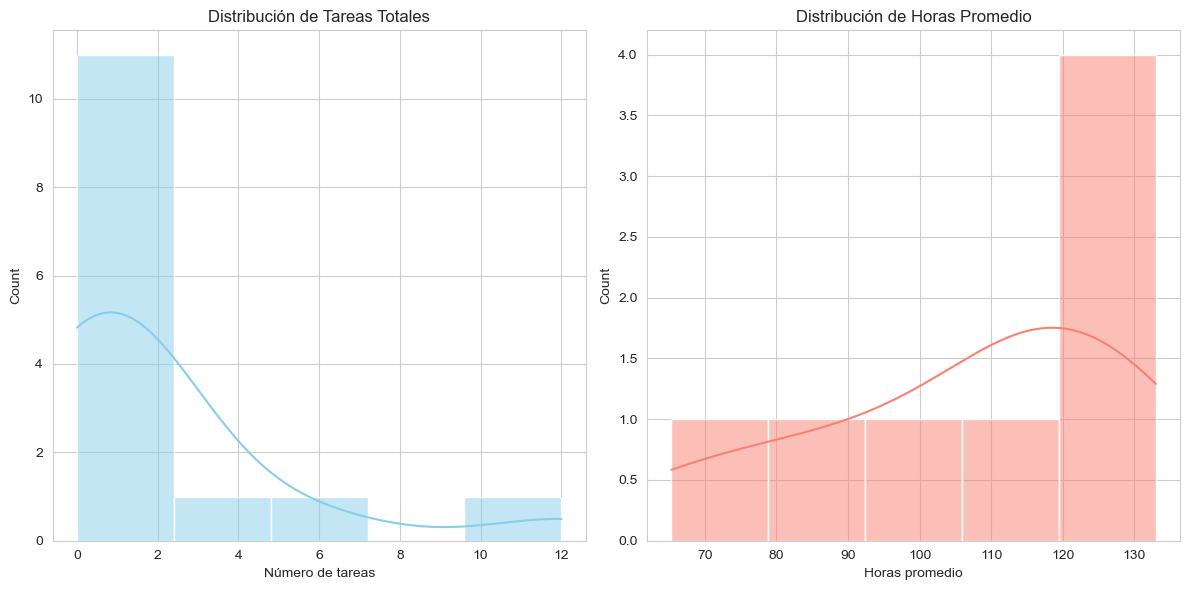

In [28]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.subplot(1, 2, 1)
sns.histplot(df['total_tareas'], bins=5, kde=True, color='skyblue')
plt.title('Distribución de Tareas Totales')
plt.xlabel('Número de tareas')

plt.subplot(1, 2, 2)
sns.histplot(df['avg_horas_para_completar'], bins=5, kde=True, color='salmon')
plt.title('Distribución de Horas Promedio')
plt.xlabel('Horas promedio')
plt.tight_layout()
plt.show()

## 4.2  Relación entre tareas y horas promedio

Permite observar si existe una tendencia entre el número de tareas y el tiempo promedio para completarlas.

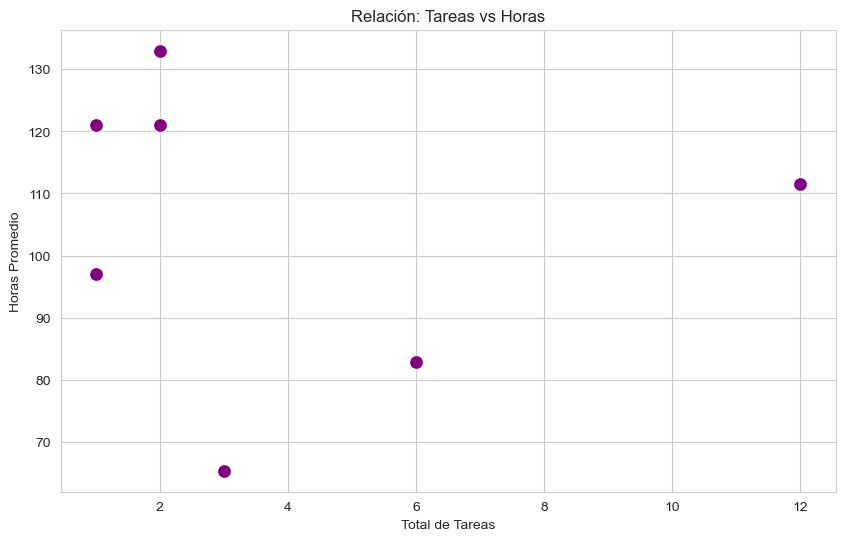

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_tareas', y='avg_horas_para_completar', data=df, s=100, color='purple')
plt.title('Relación: Tareas vs Horas')
plt.xlabel('Total de Tareas')
plt.ylabel('Horas Promedio')
plt.grid(True)
plt.show()

## 4.3 Distribución de tareas completadas

Muestra cuántos usuarios tienen 0, 1, 2 o 3 tareas completadas. Útil para detectar desbalance.

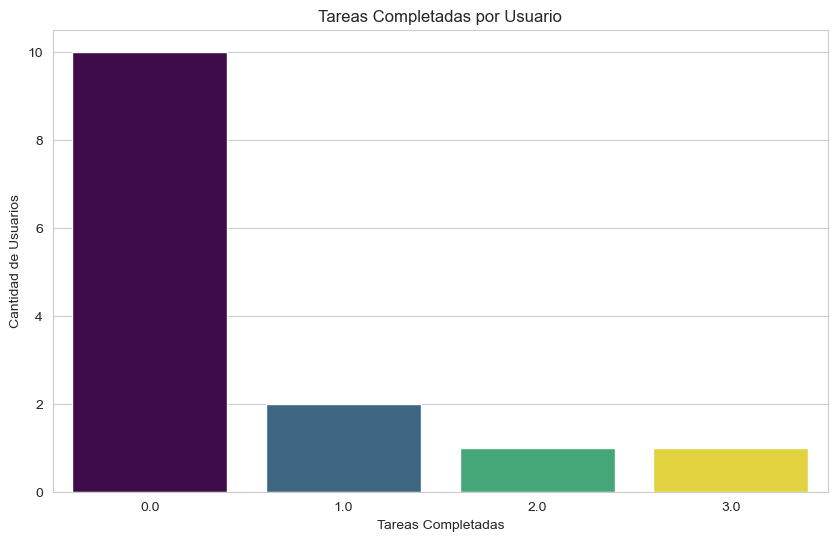

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(x='tareas_completadas', data=df, palette='viridis', hue='tareas_completadas', legend=False)
plt.title('Tareas Completadas por Usuario')
plt.xlabel('Tareas Completadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

## 4.4 Matriz de correlación

Muestra la correlación lineal entre variables. Valores cercanos a 1 o -1 indican fuerte relación.

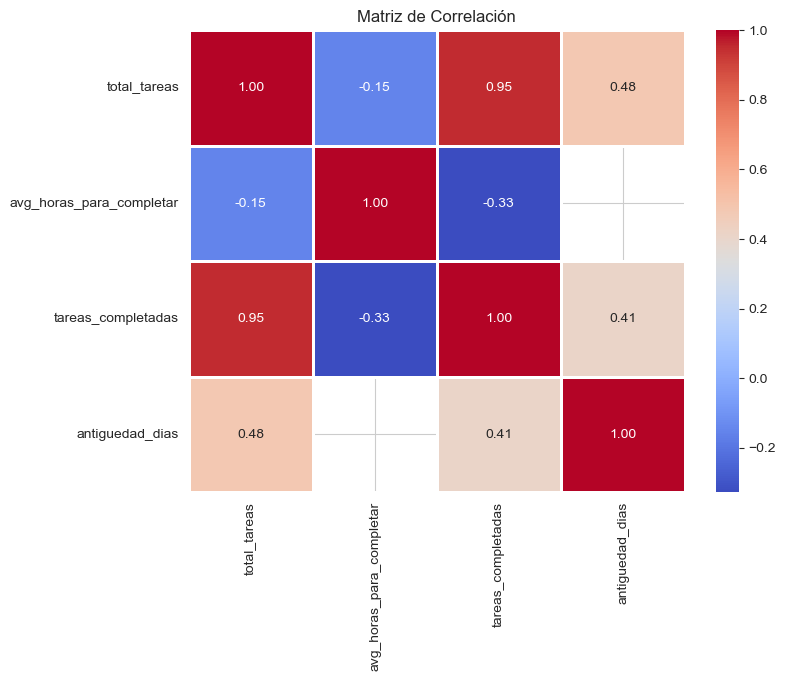

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['total_tareas', 'avg_horas_para_completar', 'tareas_completadas', 'antiguedad_dias']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Matriz de Correlación')
plt.show()

## 5. Modelo Supervisado (Random Forest Regressor)

Predice avg_horas_para_completar usando total_tareas, tareas_completadas y antiguedad_dias. Random Forest es robusto y captura relaciones no lineales. Se eliminan filas con NaN para evitar errores. Métricas: MSE (error cuadrático medio) y R² (precisión).

Resultados del Modelo Supervisado:
   - MSE: 526.72
   - R² Score: -22.76


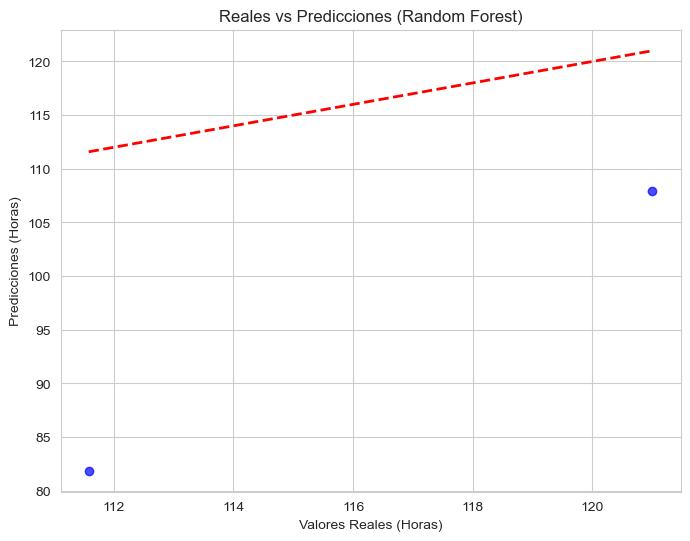

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Eliminar filas con NaN en la variable objetivo
df_sup = df.dropna(subset=['avg_horas_para_completar'])

# Seleccionar características y objetivo
X = df_sup[['total_tareas', 'tareas_completadas', 'antiguedad_dias']]
y = df_sup['avg_horas_para_completar']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
modelo_sup = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_sup.fit(X_train, y_train)

# Predecir
y_pred = modelo_sup.predict(X_test)

# Evaluar
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Resultados del Modelo Supervisado:")
print(f"   - MSE: {mse:.2f}")
print(f"   - R² Score: {r2:.2f}")

# Gráfica: Reales vs Predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (Horas)')
plt.ylabel('Predicciones (Horas)')
plt.title('Reales vs Predicciones (Random Forest)')
plt.grid(True)
plt.show()

##  5.1 Modelo Supervisado 2 - Regresión Lineal (Baseline)

In [60]:
# 5.1 Modelo Supervisado 2: Regresión Lineal
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

# Definir las métricas aquí para que estén disponibles en la comparación
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Resultados Regresión Lineal:")
print(f"   - MSE: {mse_lr:.2f}")
print(f"   - R² Score: {r2_lr:.2f}")

Resultados Regresión Lineal:
   - MSE: 1112.75
   - R² Score: -49.19


## 5.2 Modelo Supervisado 3 - Árbol de Decisión (Decision Tree)

In [61]:
# 5.2 Modelo Supervisado 3: Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor

modelo_dt = DecisionTreeRegressor(random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)

# Definir las métricas aquí
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Resultados Árbol de Decisión:")
print(f"   - MSE: {mse_dt:.2f}")
print(f"   - R² Score: {r2_dt:.2f}")

Resultados Árbol de Decisión:
   - MSE: 701.28
   - R² Score: -30.63


## 5.3 Modelo Supervisado 4 - Gradient Boosting

In [63]:
# 5.3 Modelo Supervisado 4: Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = GradientBoostingRegressor(random_state=42)
modelo_gb.fit(X_train, y_train)
y_pred_gb = modelo_gb.predict(X_test)

# Definir las métricas aquí
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Resultados Gradient Boosting:")
print(f"   - MSE: {mse_gb:.2f}")
print(f"   - R² Score: {r2_gb:.2f}")

Resultados Gradient Boosting:
   - MSE: 701.26
   - R² Score: -30.63


## 5.4  Modelo Supervisado 5 - K-Nearest Neighbors (KNN)

In [64]:
# 5.4 Modelo Supervisado 5: K-Nearest Neighbors
from sklearn.neighbors import KNeighborsRegressor

modelo_knn = KNeighborsRegressor(n_neighbors=3)
modelo_knn.fit(X_train, y_train)
y_pred_knn = modelo_knn.predict(X_test)

# Definir las métricas aquí
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("Resultados KNN:")
print(f"   - MSE: {mse_knn:.2f}")
print(f"   - R² Score: {r2_knn:.2f}")

Resultados KNN:
   - MSE: 246.95
   - R² Score: -10.14


 ##  5.5 Comparación de Modelos Supervisados

In [65]:
# 5.5 Comparación de todos los modelos supervisados
comparacion_sup = pd.DataFrame({
    'Modelo': ['Random Forest', 'Regresión Lineal', 'Árbol de Decisión', 'Gradient Boosting', 'KNN'],
    'MSE': [mse, mse_lr, mse_dt, mse_gb, mse_knn],
    'R²': [r2, r2_lr, r2_dt, r2_gb, r2_knn]
})
display(comparacion_sup.sort_values('MSE'))

print("Mejor modelo supervisado (menor MSE):")
print(comparacion_sup.loc[comparacion_sup['MSE'].idxmin(), 'Modelo'])

,Modelo,MSE,R²
4,KNN,246.953847,-10.139824
0,Random Forest,526.718153,-22.759692
3,Gradient Boosting,701.261519,-30.633157
2,Árbol de Decisión,701.281250,-30.634047
1,Regresión Lineal,1112.745707,-49.194768


Mejor modelo supervisado (menor MSE):
KNN


## 6. Modelo No Supervisado (K-Means Clustering)

Agrupa usuarios en clusters según su comportamiento. K-Means minimiza la distancia entre puntos y centroides. Se escala con StandardScaler (K-Means es sensible a la escala). Se usa Silhouette Score para elegir el mejor K.

C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

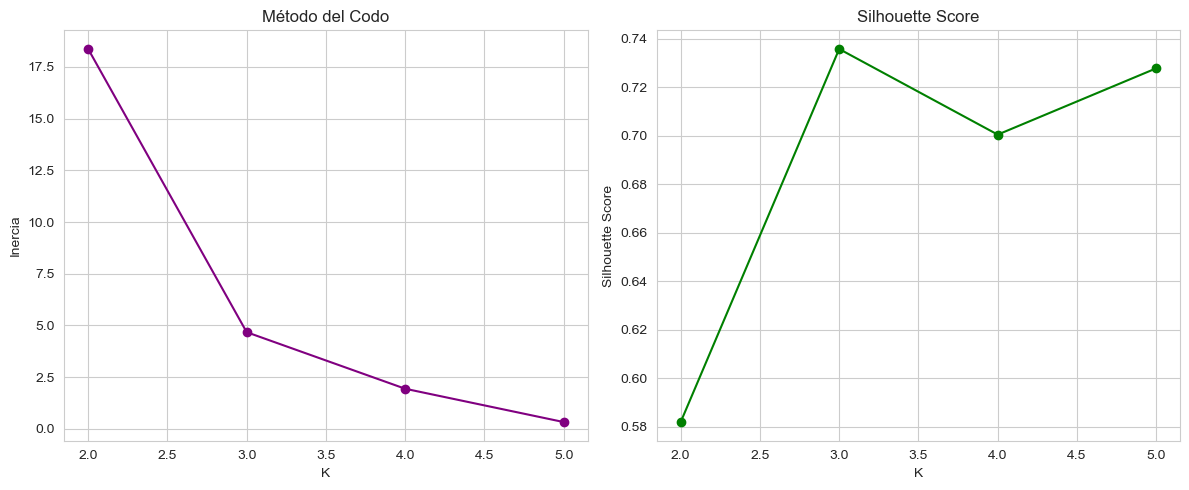

Mejor K: 3


In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Preparar datos y escalar
X_cluster = df[['total_tareas', 'tareas_completadas', 'antiguedad_dias']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Probar K de 2 a 5
inertias = []
sil_scores = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráficas del codo y Silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', color='purple')
plt.title('Método del Codo')
plt.xlabel('K')
plt.ylabel('Inercia')

plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Mejor K
best_k = K_range[np.argmax(sil_scores)]
print(f"Mejor K: {best_k}")

## 6.1 Modelo No Supervisado 2 - DBSCAN

In [50]:
# 6.1 Modelo No Supervisado 2: DBSCAN
from sklearn.cluster import DBSCAN

modelo_dbscan = DBSCAN(eps=0.5, min_samples=2)
labels_dbscan = modelo_dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f" DBSCAN: {n_clusters_dbscan} clusters encontrados")

 DBSCAN: 3 clusters encontrados


## 6.2 Modelo No Supervisado 3 - Clustering Jerárquico (Agglomerative)

In [52]:
# 6.2 Modelo No Supervisado 3: Clustering Jerárquico
from sklearn.cluster import AgglomerativeClustering

modelo_agg = AgglomerativeClustering(n_clusters=3)
labels_agg = modelo_agg.fit_predict(X_scaled)

print("Clustering Jerárquico aplicado con 3 clusters")

Clustering Jerárquico aplicado con 3 clusters


## Celda 6.3 Modelo No Supervisado 4 - Gaussian Mixture (GMM)

In [54]:
# 6.3 Modelo No Supervisado 4: Gaussian Mixture
from sklearn.mixture import GaussianMixture

modelo_gmm = GaussianMixture(n_components=3, random_state=42)
modelo_gmm.fit(X_scaled)
labels_gmm = modelo_gmm.predict(X_scaled)

print("Gaussian Mixture aplicado con 3 componentes")

Gaussian Mixture aplicado con 3 componentes


C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 6.4 Modelo No Supervisado 5 - Mini-Batch K-Means

In [56]:
# 6.4 Modelo No Supervisado 5: Mini-Batch K-Means (para grandes volúmenes)
from sklearn.cluster import MiniBatchKMeans

modelo_mbk = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=10)
modelo_mbk.fit(X_scaled)
labels_mbk = modelo_mbk.predict(X_scaled)

print("Mini-Batch K-Means aplicado con 3 clusters")

C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


Mini-Batch K-Means aplicado con 3 clusters


## 6.5 Comparación de Modelos No Supervisados

In [59]:
# 6.5 Comparación de modelos no supervisados
comparacion_unsup = pd.DataFrame({
    'Modelo': ['K-Means', 'DBSCAN', 'Jerárquico', 'Gaussian Mixture', 'Mini-Batch K-Means'],
    'N_Clusters': [best_k, n_clusters_dbscan, 3, 3, 3]
})
display(comparacion_unsup)

print("Modelo seleccionado para despliegue: K-Means (por su interpretabilidad y Silhouette Score)")

,Modelo,N_Clusters
0,K-Means,3
1,DBSCAN,3
2,Jerárquico,3
3,Gaussian Mixture,3
4,Mini-Batch K-Means,3


Modelo seleccionado para despliegue: K-Means (por su interpretabilidad y Silhouette Score)


## 7. Aplicar K-Means y visualizar clusters

Aplica K-Means con el mejor K, asigna clusters a cada usuario y muestra el perfil promedio de cada grupo (cuántas tareas, horas, etc.). La visualización ayuda a interpretar los segmentos.

Perfil de cada cluster:


C:\Users\mctec\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,total_tareas,avg_horas_para_completar,tareas_completadas,antiguedad_dias
cluster,,,,
0,1.57,109.72,0.29,41.0
1,0.00,NaN,0.00,0.0
2,9.00,97.21,2.50,41.0


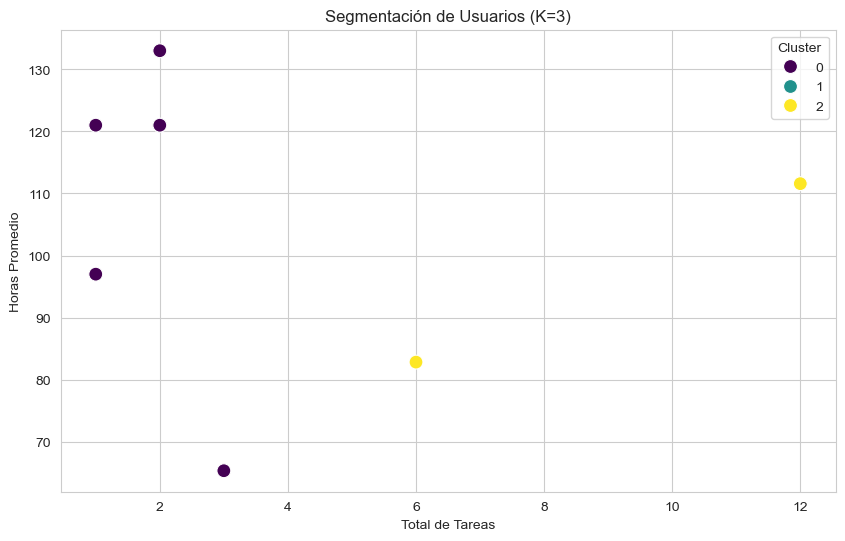

In [67]:

# Verificar que best_k esté definido
if 'best_k' not in locals():
    print(" Ejecuta la Celda 6 primero para obtener el mejor K.")
else:
    kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df['cluster'] = kmeans_final.fit_predict(X_scaled)

    print("Perfil de cada cluster:")
    cluster_profile = df.groupby('cluster').agg({
        'total_tareas': 'mean',
        'avg_horas_para_completar': 'mean',
        'tareas_completadas': 'mean',
        'antiguedad_dias': 'mean'
    }).round(2)
    display(cluster_profile)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='total_tareas', y='avg_horas_para_completar', hue='cluster', data=df, palette='viridis', s=100)
    plt.title(f'Segmentación de Usuarios (K={best_k})')
    plt.xlabel('Total de Tareas')
    plt.ylabel('Horas Promedio')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

## 8. Conclusiones finales

Resume los resultados del modelo supervisado y no supervisado. Se interpretan los clusters y se proponen mejoras futuras (más datos, integración con frontend, reentrenamiento periódico).

In [68]:
# 8. Conclusiones finales

print("CONCLUSIONES")

# Verificar que las variables del modelo supervisado existan
if 'mse' not in locals() or 'r2' not in locals():
    print("No se pudo evaluar el modelo supervisado. Ejecuta las celdas 5 a 5.4 en orden.")
else:
    print("\n1. Modelo Supervisado (Random Forest):")
    print(f"   - MSE: {mse:.2f} horas")
    print(f"   - R² Score: {r2:.2f}")

# Verificar que cluster_profile exista
if 'cluster_profile' not in locals():
    print("\nNo se pudo evaluar el modelo no supervisado. Ejecuta la Celda 7.")
else:
    print("\n2. Modelo No Supervisado (K-Means):")
    print(f"   - Mejor K: {best_k}")
    for i in range(best_k):
        perfil = cluster_profile.loc[i]
        print(f"     * Cluster {i}: {perfil['total_tareas']:.1f} tareas, {perfil['avg_horas_para_completar']:.1f} horas")

print("\n3. Próximos pasos:")
print("   - Insertar más datos para mejorar precisión.")
print("   - Integrar con el frontend.")
print("   - Reentrenar periódicamente.")

print("\nAnálisis completado.")

CONCLUSIONES

1. Modelo Supervisado (Random Forest):
   - MSE: 526.72 horas
   - R² Score: -22.76

2. Modelo No Supervisado (K-Means):
   - Mejor K: 3
     * Cluster 0: 1.6 tareas, 109.7 horas
     * Cluster 1: 0.0 tareas, nan horas
     * Cluster 2: 9.0 tareas, 97.2 horas

3. Próximos pasos:
   - Insertar más datos para mejorar precisión.
   - Integrar con el frontend.
   - Reentrenar periódicamente.

Análisis completado.


## Resumen final del notebook



| Aspecto | Descripción |
| :--- | :--- |
| **Entrada** | Datos extraídos de la vista `vw_ml_data` en MySQL (Data Mart analítico). |
| **Procesamiento** | Análisis exploratorio (EDA), entrenamiento de 5 modelos supervisados, entrenamiento de 5 modelos no supervisados, comparación y selección de los mejores. |
| **Salida** | Modelos evaluados y seleccionados para integración en la API híbrida (Node.js + Python). |
